# LSEG Data Pull — NetPayout

Dieses Notebook nutzt nur den `lseg_series_puller`.

Pipeline:
- `1.` Setup
- `2.` Input + Run-Konfiguration
- `3.` Optionaler Reset (Fresh Run)
- `4.` Standard-Puller-Setup
- `5.` NP1 Pull (Balance Sheet)
- `6.` NP2 Pull (Income Statement)
- `7.` NP3 Pull (Payout + Liquidity)
- `8.` NP4 Pull (Market Cap)
- `9.` Quick Check


## 0. Setup



In [16]:
from pathlib import Path
import shutil
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from lseg_series_puller import (
    SeriesPullConfig,
    SeriesFieldSpec,
    run_standard_pull,
)
from plot_style import COLORS, set_global_plot_style, style_axes, style_legend, style_time_axis

warnings.filterwarnings("ignore", category=FutureWarning, module="lseg")
pd.set_option("display.max_columns", 200)
set_global_plot_style()


## 2. Input + Run-Konfiguration

Geladene Basisdaten:
- `Project_Data/intermediate/euro500.parquet`

Verwendete Schlüsselspalten:
- `firm_id`
- `date`
- (ID-Fallback aus vorhandenen Spalten wie `ISIN`, `RIC_current`, `RIC`, `id_type`, `pull_id`)



In [17]:
from project_paths import BASE_DIR, DATA_DIR, CACHE_DATA_DIR

BASE_PATH = DATA_DIR / 'euro500.parquet'
OUTPUT_PATH = DATA_DIR / 'euro500_netpayout.parquet'

if not BASE_PATH.exists():
    raise FileNotFoundError(f'Missing file: {BASE_PATH}')

base = pd.read_parquet(BASE_PATH).copy()
if 'date' not in base.columns or 'firm_id' not in base.columns:
    raise ValueError('euro500.parquet must contain at least firm_id and date columns.')

print('Loaded base:', BASE_PATH)
print('rows:', len(base), '| companies:', base['firm_id'].nunique())
print('date range:', pd.to_datetime(base['date'], errors='coerce').min(), '->', pd.to_datetime(base['date'], errors='coerce').max())

# ---------- Run control ----------
# Für komplettes Neuziehen: beide Flags auf True lassen.
RESET_PULL_STATE = False
FORCE_REFRESH_ALL = False
RUN_LSEG_PULL = True
BATCH_SIZE = 10
ASOF_TOL_DAYS = 365
DEBUG_RAW_FIRST_N = 0
PRE_INDEX_PREFETCH_YEARS = 2

# Wenn True, wird auch das finale Output-Parquet entfernt und neu aufgebaut.
RESET_OUTPUT_FILE = False





Loaded base: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/euro500.parquet
rows: 56500 | companies: 1248
date range: 1997-12-31 00:00:00 -> 2025-12-31 00:00:00


## 3. Reset (optional, für kompletten Neu-Pull)

Wenn aktiviert, werden pro Modul (`NP1/NP2/NP3/NP4`) gelöscht:
- Cache-Verzeichnisse (`*_cache_by_company_id`)
- `step_rows`-Dateien
- `checkpoint`-Dateien
- `bad_ids`-Dateien
- `bad_rows`-Logs
- optional das kombinierte Output-File `euro500_netpayout.parquet`


In [18]:
MODULES = {
    'NP1': {
        'cache_dir': CACHE_DATA_DIR / 'np1_cache_by_company_id',
        'step_rows_path': CACHE_DATA_DIR / 'np1_step_rows.parquet',
        'checkpoint_path': CACHE_DATA_DIR / 'np1_checkpoint.json',
        'bad_ids_path': CACHE_DATA_DIR / 'np1_bad_ids.csv',
        'bad_rows_log_path': CACHE_DATA_DIR / 'np1_bad_rows.parquet',
    },
    'NP2': {
        'cache_dir': CACHE_DATA_DIR / 'np2_cache_by_company_id',
        'step_rows_path': CACHE_DATA_DIR / 'np2_step_rows.parquet',
        'checkpoint_path': CACHE_DATA_DIR / 'np2_checkpoint.json',
        'bad_ids_path': CACHE_DATA_DIR / 'np2_bad_ids.csv',
        'bad_rows_log_path': CACHE_DATA_DIR / 'np2_bad_rows.parquet',
    },
    'NP3': {
        'cache_dir': CACHE_DATA_DIR / 'np3_cache_by_company_id',
        'step_rows_path': CACHE_DATA_DIR / 'np3_step_rows.parquet',
        'checkpoint_path': CACHE_DATA_DIR / 'np3_checkpoint.json',
        'bad_ids_path': CACHE_DATA_DIR / 'np3_bad_ids.csv',
        'bad_rows_log_path': CACHE_DATA_DIR / 'np3_bad_rows.parquet',
    },
    'NP4': {
        'cache_dir': CACHE_DATA_DIR / 'np4_cache_by_company_id',
        'step_rows_path': CACHE_DATA_DIR / 'np4_step_rows.parquet',
        'checkpoint_path': CACHE_DATA_DIR / 'np4_checkpoint.json',
        'bad_ids_path': CACHE_DATA_DIR / 'np4_bad_ids.csv',
        'bad_rows_log_path': CACHE_DATA_DIR / 'np4_bad_rows.parquet',
    },
}

if RESET_PULL_STATE:
    print('Resetting NP pull state...')
    for name, m in MODULES.items():
        if m['cache_dir'].exists():
            shutil.rmtree(m['cache_dir'])
            print(f'  removed cache dir: {m["cache_dir"]}')
        for k in ['step_rows_path', 'checkpoint_path', 'bad_ids_path', 'bad_rows_log_path']:
            fp = m[k]
            if fp.exists():
                fp.unlink()
                print(f'  removed {name} {k}: {fp}')

if RESET_OUTPUT_FILE and OUTPUT_PATH.exists():
    OUTPUT_PATH.unlink()
    print('Removed old output:', OUTPUT_PATH)


## 4. Standard Puller Setup


In [19]:
def run_np_module(
    source_df: pd.DataFrame,
    module_name: str,
    specs: tuple[SeriesFieldSpec, ...],
    primary_output_col: str,
) -> dict:
    m = MODULES[module_name]

    cfg = SeriesPullConfig(
        batch_size=BATCH_SIZE,
        asof_tolerance_days=ASOF_TOL_DAYS,
        prefetch_start_days=int(PRE_INDEX_PREFETCH_YEARS * 365),
        debug_raw_first_n=DEBUG_RAW_FIRST_N,
        force_refresh=FORCE_REFRESH_ALL,
        cache_only=(not RUN_LSEG_PULL),
        skip_known_bad_ids=True,
        max_retries=3,
        base_sleep_sec=0.7,
        series_specs=specs,
        primary_output_col=primary_output_col,
    )

    print('\n' + '=' * 90)
    print(f'RUN {module_name}')
    print('=' * 90)

    res = run_standard_pull(
        pull_type='series',
        source_df=source_df,
        config=cfg,
        cache_dir=m['cache_dir'],
        step_rows_path=m['step_rows_path'],
        checkpoint_path=m['checkpoint_path'],
        bad_ids_path=m['bad_ids_path'],
        bad_rows_log_path=m['bad_rows_log_path'],
        skip_filled_primary=False,
        merge_back=True,
        diag_prefix=f'{module_name.lower()}_',
    )

    print(f"{module_name} stats:", res['stats'])
    return res


NP1_SPECS = (
    SeriesFieldSpec(output_col='BE', fields=('TR.F.COMEQTOT(Period=FY0)',)),
    SeriesFieldSpec(output_col='assets', fields=('TR.F.TOTASSETS(Period=FY0)',)),
    SeriesFieldSpec(output_col='debt', fields=('TR.F.DEBTTOT(Period=FY0)',)),
)

NP2_SPECS = (
    SeriesFieldSpec(output_col='Sales', fields=('TR.F.TotRevenue(Period=FY0)',)),
    SeriesFieldSpec(output_col='NetIncome', fields=('TR.F.NetIncAfterTax(Period=FY0)',)),
    SeriesFieldSpec(output_col='GrossProfit', fields=('TR.F.GrossProfIndPropTot(Period=FY0)',)),
    SeriesFieldSpec(output_col='Cogs', fields=('TR.F.COGSTot(Period=FY0)',)),
)

# CashSTInvst ist bewusst in NP3 integriert.
NP3_SPECS = (
    SeriesFieldSpec(output_col='Dividends', fields=('TR.F.DivPaidCashTotCF(Period=FY0)',)),
    SeriesFieldSpec(output_col='Buybacks', fields=('TR.F.ComStockBuybackNet(Period=FY0)',)),
    SeriesFieldSpec(output_col='CashSTInvst', fields=('TR.F.CashSTInvst(Period=FY0)',)),
)

NP4_SPECS = (
    SeriesFieldSpec(output_col='mcap_eur', fields=('TR.CompanyMarketCap',)),
)


def coverage_by_quarter(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    x = df.copy()
    x['date'] = pd.to_datetime(x['date'], errors='coerce').dt.normalize()
    x = x.dropna(subset=['firm_id', 'date']).copy()
    x['quarter'] = x['date'].dt.to_period('Q').dt.to_timestamp(how='end').dt.normalize()

    rows = []
    for q, g in x.groupby('quarter', sort=True):
        rec = {
            'quarter': q,
            'n_obs': int(len(g)),
            'n_firms': int(g['firm_id'].nunique()),
        }
        for col in cols:
            if col in g.columns:
                rec[f'cov_{col}_pct'] = round(float(pd.to_numeric(g[col], errors='coerce').notna().mean() * 100.0), 2)
            else:
                rec[f'cov_{col}_pct'] = np.nan
        rows.append(rec)

    out = pd.DataFrame(rows).sort_values('quarter').reset_index(drop=True)
    return out



## 5. NP1 (Balance Sheet)

In NP1 geladene LSEG-Daten (FY):
- `TR.F.COMEQTOT(Period=FY0)` -> `BE`
- `TR.F.TOTASSETS(Period=FY0)` -> `assets`
- `TR.F.DEBTTOT(Period=FY0)` -> `debt`

Merge-Ziel:
- zurück auf `euro500` über `firm_id,date`



In [20]:
np1 = run_np_module(base, 'NP1', NP1_SPECS, primary_output_col='BE')
np1_df = np1['merged_df'].copy()
print('NP1 done: rows=', len(np1_df), '| companies=', np1_df['firm_id'].nunique())



RUN NP1

Standard Series Pull Overview
series_specs: BE<-['TR.F.COMEQTOT(Period=FY0)'], assets<-['TR.F.TOTASSETS(Period=FY0)'], debt<-['TR.F.DEBTTOT(Period=FY0)']
request_rows: 56,500
coverage: all_companies=1,248 | full_coverage=802 | partial_coverage=313 | bad_ids=133 | remaining=0
mode: CACHE+NETWORK | batch_size: 10
Done: companies_total=1248, run_remaining_start=0, candidate_calls=0, resolved_rows=0, unresolved_rows=0, found_BE=0, full_coverage=802, partial_coverage=313, bad_ids=133, bad_id_skip=133, bad_ids_added=0, known_bad_ids_now=133
NP1 stats: {'companies_total': 1248, 'full_coverage': 802, 'partial_coverage': 313, 'bad_ids': 133, 'remaining': 0, 'run_remaining_start': 0, 'candidate_calls': 0, 'resolved_rows': 0, 'unresolved_rows': 0, 'bad_id_skip': 133, 'bad_ids_added': 0, 'known_bad_ids_now': 133}
NP1 done: rows= 56500 | companies= 1248


### 5.1 NP1 Coverage nach Quartal



In [21]:
np1_cov_q = coverage_by_quarter(np1_df, ['BE', 'assets', 'debt'])
np1_cov_q

,quarter,n_obs,n_firms,cov_BE_pct,cov_assets_pct,cov_debt_pct
0,1997-12-31,500,500,62.2,62.4,59.8
1,1998-03-31,500,500,66.4,66.6,64.4
2,1998-06-30,500,500,68.8,69.2,67.0
3,1998-09-30,500,500,70.8,71.2,69.2
4,1998-12-31,500,500,88.4,88.6,85.4
...,...,...,...,...,...,...
108,2024-12-31,500,500,97.6,97.6,97.2
109,2025-03-31,500,500,98.8,98.8,98.4
110,2025-06-30,500,500,99.0,99.0,98.6
111,2025-09-30,500,500,98.6,98.6,98.2


## 6. NP2 (Income Statement)

In NP2 geladene LSEG-Daten (FY):
- `TR.F.TotRevenue(Period=FY0)` -> `Sales`
- `TR.F.NetIncAfterTax(Period=FY0)` -> `NetIncome`
- `TR.F.GrossProfIndPropTot(Period=FY0)` -> `GrossProfit`
- `TR.F.COGSTot(Period=FY0)` -> `Cogs`

Merge-Ziel:
- Update des NP1-Outputs über `firm_id,date`



In [22]:
_np2_input = np1_df if 'np1_df' in globals() else base
np2 = run_np_module(_np2_input, 'NP2', NP2_SPECS, primary_output_col='Sales')
np2_df = np2['merged_df'].copy()
print('NP2 done: rows=', len(np2_df), '| companies=', np2_df['firm_id'].nunique())



RUN NP2

Standard Series Pull Overview
series_specs: Sales<-['TR.F.TotRevenue(Period=FY0)'], NetIncome<-['TR.F.NetIncAfterTax(Period=FY0)'], GrossProfit<-['TR.F.GrossProfIndPropTot(Period=FY0)'], Cogs<-['TR.F.COGSTot(Period=FY0)']
request_rows: 56,500
coverage: all_companies=1,248 | full_coverage=821 | partial_coverage=279 | bad_ids=148 | remaining=0
mode: CACHE+NETWORK | batch_size: 10
Done: companies_total=1248, run_remaining_start=0, candidate_calls=0, resolved_rows=0, unresolved_rows=0, found_Sales=0, full_coverage=821, partial_coverage=279, bad_ids=148, bad_id_skip=148, bad_ids_added=0, known_bad_ids_now=148
NP2 stats: {'companies_total': 1248, 'full_coverage': 821, 'partial_coverage': 279, 'bad_ids': 148, 'remaining': 0, 'run_remaining_start': 0, 'candidate_calls': 0, 'resolved_rows': 0, 'unresolved_rows': 0, 'bad_id_skip': 148, 'bad_ids_added': 0, 'known_bad_ids_now': 148}
NP2 done: rows= 56500 | companies= 1248


### 6.1 NP2 Coverage nach Quartal



In [23]:
np2_cov_q = coverage_by_quarter(np2_df, ['Sales', 'NetIncome', 'GrossProfit', 'Cogs'])
np2_cov_q


,quarter,n_obs,n_firms,cov_Sales_pct,cov_NetIncome_pct,cov_GrossProfit_pct,cov_Cogs_pct
0,1997-12-31,500,500,61.0,61.2,54.4,48.6
1,1998-03-31,500,500,65.2,65.2,58.2,52.0
2,1998-06-30,500,500,67.8,67.8,60.8,54.2
3,1998-09-30,500,500,69.8,69.8,62.8,56.4
4,1998-12-31,500,500,86.2,86.4,77.8,72.4
...,...,...,...,...,...,...,...
108,2024-12-31,500,500,96.0,96.2,82.6,78.4
109,2025-03-31,500,500,97.2,97.4,84.0,79.8
110,2025-06-30,500,500,97.4,97.6,84.2,80.0
111,2025-09-30,500,500,97.0,97.2,83.4,79.0


## 7. NP3 (Payout + Liquidity)

In NP3 geladene LSEG-Daten (FY):
- `TR.F.DivPaidCashTotCF(Period=FY0)` -> `Dividends`
- `TR.F.ComStockBuybackNet(Period=FY0)` -> `Buybacks`
- `TR.F.CashSTInvst(Period=FY0)` -> `CashSTInvst`

Definition / Interpretation fuer Net-Payout:
- `Buybacks` basiert auf `SCSBN` (Common Stock Buyback - Net).
- Damit ist Issuance bereits gegengerechnet; negative Werte sind moeglich (Netto-Emission).
- `PO = Dividends + Buybacks` ist in dieser Spezifikation konsistent.

Merge-Ziel:
- Update des NP2-Outputs ueber `firm_id,date`
- finaler Export nach `Project_Data/intermediate/euro500_netpayout.parquet`



In [24]:
_np3_input = np2_df if 'np2_df' in globals() else (np1_df if 'np1_df' in globals() else base)
np3 = run_np_module(_np3_input, 'NP3', NP3_SPECS, primary_output_col='Dividends')
np3_df = np3['merged_df'].copy()
np3_df['date'] = pd.to_datetime(np3_df['date'], errors='coerce').dt.normalize()
np3_df = np3_df.dropna(subset=['firm_id', 'date']).sort_values(['firm_id', 'date']).drop_duplicates(['firm_id', 'date'], keep='last')

print('NP3 done: rows=', len(np3_df), '| companies=', np3_df['firm_id'].nunique())




RUN NP3

Standard Series Pull Overview
series_specs: Dividends<-['TR.F.DivPaidCashTotCF(Period=FY0)'], Buybacks<-['TR.F.ComStockBuybackNet(Period=FY0)'], CashSTInvst<-['TR.F.CashSTInvst(Period=FY0)']
request_rows: 56,500
coverage: all_companies=1,248 | full_coverage=305 | partial_coverage=598 | bad_ids=345 | remaining=0
mode: CACHE+NETWORK | batch_size: 10
Done: companies_total=1248, run_remaining_start=0, candidate_calls=0, resolved_rows=0, unresolved_rows=0, found_Dividends=0, full_coverage=305, partial_coverage=598, bad_ids=345, bad_id_skip=345, bad_ids_added=0, known_bad_ids_now=345
NP3 stats: {'companies_total': 1248, 'full_coverage': 305, 'partial_coverage': 598, 'bad_ids': 345, 'remaining': 0, 'run_remaining_start': 0, 'candidate_calls': 0, 'resolved_rows': 0, 'unresolved_rows': 0, 'bad_id_skip': 345, 'bad_ids_added': 0, 'known_bad_ids_now': 345}
NP3 done: rows= 56500 | companies= 1248


### 7.1 NP3 Coverage nach Quartal



In [25]:
np3_cov_q = coverage_by_quarter(np3_df, ['Dividends', 'Buybacks', 'CashSTInvst'])
np3_cov_q



,quarter,n_obs,n_firms,cov_Dividends_pct,cov_Buybacks_pct,cov_CashSTInvst_pct
0,1997-12-31,500,500,35.2,23.6,57.4
1,1998-03-31,500,500,37.4,25.4,61.0
2,1998-06-30,500,500,38.0,26.8,63.4
3,1998-09-30,500,500,39.2,27.6,65.4
4,1998-12-31,500,500,52.0,37.2,83.0
...,...,...,...,...,...,...
108,2024-12-31,500,500,87.4,69.6,95.2
109,2025-03-31,500,500,89.4,69.6,96.4
110,2025-06-30,500,500,89.4,70.4,96.6
111,2025-09-30,500,500,88.4,69.6,95.8


## 8. NP4 (Market Cap)

In NP4 geladene LSEG-Daten:
- `TR.CompanyMarketCap` -> `mcap_eur`

Merge-Ziel:
- Update des NP3-Outputs ueber `firm_id,date`
- Market Cap moeglichst stichtagsnah je Zeile (`firm_id,date`)



In [26]:
_np4_input = np3_df if 'np3_df' in globals() else (np2_df if 'np2_df' in globals() else base)
np4 = run_np_module(_np4_input, 'NP4', NP4_SPECS, primary_output_col='mcap_eur')
out = np4['merged_df'].copy()
out['date'] = pd.to_datetime(out['date'], errors='coerce').dt.normalize()
out = out.dropna(subset=['firm_id', 'date']).sort_values(['firm_id', 'date']).drop_duplicates(['firm_id', 'date'], keep='last')
euro500_netpayout_df = out.copy()
print('Prepared NP4 merged panel in memory: rows=', len(out), '| companies=', out['firm_id'].nunique())




RUN NP4

Standard Series Pull Overview
series_specs: mcap_eur<-['TR.CompanyMarketCap']
request_rows: 56,500
coverage: all_companies=1,248 | full_coverage=1,245 | partial_coverage=2 | bad_ids=1 | remaining=0
mode: CACHE+NETWORK | batch_size: 10
Done: companies_total=1248, run_remaining_start=0, candidate_calls=0, resolved_rows=0, unresolved_rows=0, found_mcap_eur=0, full_coverage=1245, partial_coverage=2, bad_ids=1, bad_id_skip=1, bad_ids_added=0, known_bad_ids_now=1
NP4 stats: {'companies_total': 1248, 'full_coverage': 1245, 'partial_coverage': 2, 'bad_ids': 1, 'remaining': 0, 'run_remaining_start': 0, 'candidate_calls': 0, 'resolved_rows': 0, 'unresolved_rows': 0, 'bad_id_skip': 1, 'bad_ids_added': 0, 'known_bad_ids_now': 1}
Prepared NP4 merged panel in memory: rows= 56500 | companies= 1248


### 8.1 NP4 Coverage nach Quartal


In [27]:
np4_cov_q = coverage_by_quarter(euro500_netpayout_df, ['mcap_eur'])
np4_cov_q



,quarter,n_obs,n_firms,cov_mcap_eur_pct
0,1997-12-31,500,500,100.0
1,1998-03-31,500,500,100.0
2,1998-06-30,500,500,100.0
3,1998-09-30,500,500,100.0
4,1998-12-31,500,500,100.0
...,...,...,...,...
108,2024-12-31,500,500,100.0
109,2025-03-31,500,500,100.0
110,2025-06-30,500,500,100.0
111,2025-09-30,500,500,100.0


## 9. Coverage-Plot nach Quartal

Kombinierte Quartals-Coverage der 10 Kern-Items im Stil von `plot_style.py`:
- `BE`, `assets`, `debt`
- `Sales`, `NetIncome`, `GrossProfit`, `Cogs`
- `Dividends`, `Buybacks`, `mcap_eur`



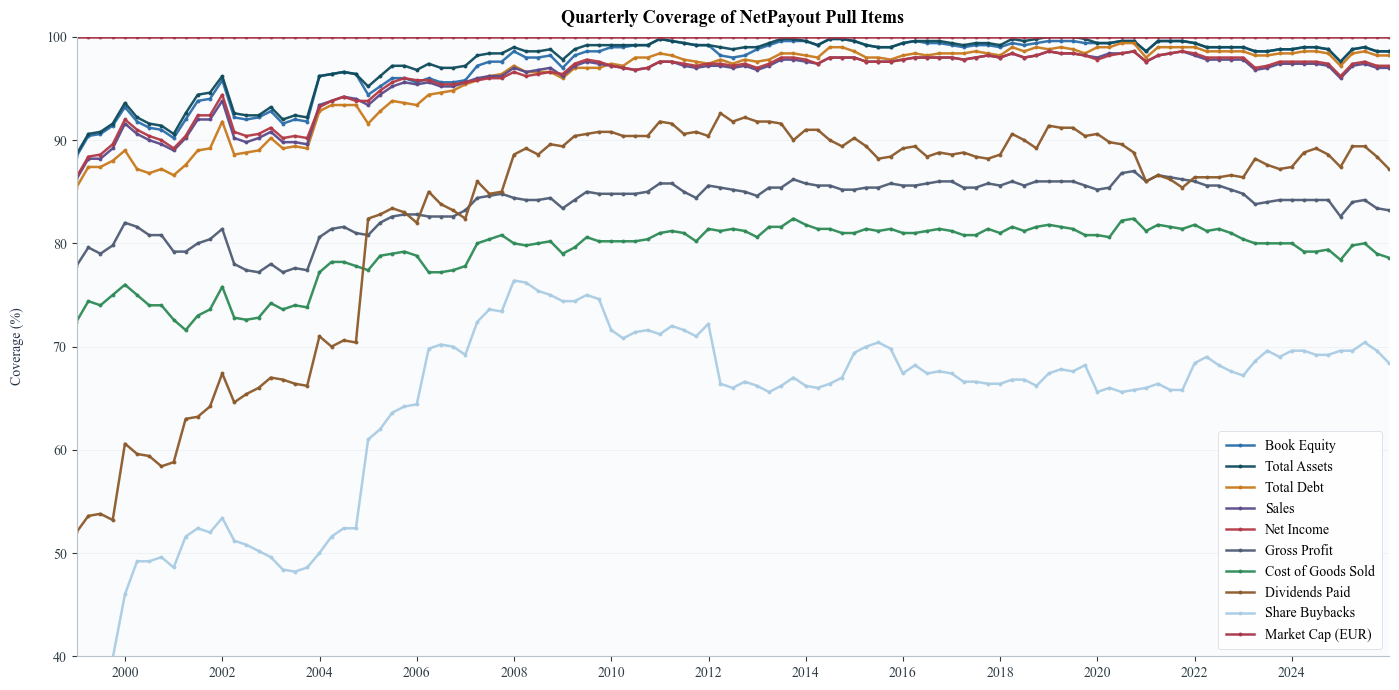

In [28]:
plot_items = [
    ('BE', 'Book Equity'),
    ('assets', 'Total Assets'),
    ('debt', 'Total Debt'),
    ('Sales', 'Sales'),
    ('NetIncome', 'Net Income'),
    ('GrossProfit', 'Gross Profit'),
    ('Cogs', 'Cost of Goods Sold'),
    ('Dividends', 'Dividends Paid'),
    ('Buybacks', 'Share Buybacks'),
    ('mcap_eur', 'Market Cap (EUR)'),
]

coverage_frames = [
    np1_cov_q[['quarter'] + [f'cov_{c}_pct' for c in ['BE', 'assets', 'debt']]].copy(),
    np2_cov_q[['quarter'] + [f'cov_{c}_pct' for c in ['Sales', 'NetIncome', 'GrossProfit', 'Cogs']]].copy(),
    np3_cov_q[['quarter'] + [f'cov_{c}_pct' for c in ['Dividends', 'Buybacks']]].copy(),
    np4_cov_q[['quarter'] + [f'cov_{c}_pct' for c in ['mcap_eur']]].copy(),
]

coverage_plot_df = coverage_frames[0]
for frame in coverage_frames[1:]:
    coverage_plot_df = coverage_plot_df.merge(frame, on='quarter', how='outer')

coverage_plot_df = coverage_plot_df.sort_values('quarter').reset_index(drop=True)

line_colors = [
    COLORS['blue'],
    COLORS['primary'],
    COLORS['orange'],
    COLORS['purple'],
    COLORS['accent'],
    COLORS['neutral'],
    COLORS['green'],
    COLORS['brown'],
    COLORS['blue_light'],
    COLORS['red'],
]

fig, ax = plt.subplots(figsize=(14, 7))

for (item, label), color in zip(plot_items, line_colors):
    col = f'cov_{item}_pct'
    if col not in coverage_plot_df.columns:
        continue
    ax.plot(
        coverage_plot_df['quarter'],
        coverage_plot_df[col],
        label=label,
        color=color,
        linewidth=1.8,
        marker='o',
        markersize=2.8,
        markeredgewidth=0.0,
        alpha=0.95,
    )

ax.set_title('Quarterly Coverage of NetPayout Pull Items')
ax.set_ylabel('Coverage (%)')
ax.set_ylim(40, 100)

style_axes(ax, grid_axis='y', grid_alpha=0.3)
style_time_axis(
    ax,
    x_min=coverage_plot_df['quarter'].min(),
    x_max=coverage_plot_df['quarter'].max(),
    x_ticks=coverage_plot_df['quarter'],
    date_fmt='%Y',
)
style_legend(ax, loc='lower right', title=None)

graphs_dir = BASE_DIR / 'graphs'
graphs_dir.mkdir(parents=True, exist_ok=True)
coverage_plot_path = graphs_dir / 'netpayout_coverage_quarterly.png'

fig.tight_layout()
fig.savefig(coverage_plot_path, dpi=220, bbox_inches='tight')

plt.show()



## 10. Finaler Output: Eine Tabelle mit allen gezogenen Items

Der einzige Tabellen-Output ist `euro500_netpayout.parquet`.
Er enthaelt genau eine Zeile je `firm_id,date` mit allen gezogenen NP-Items.
Keine zusaetzlichen Firmen-Metadaten werden angehaengt.


In [29]:
FULL_HISTORY_BASE_COLS = ['BE', 'assets', 'debt', 'Sales', 'NetIncome', 'GrossProfit', 'Cogs', 'Dividends', 'Buybacks', 'CashSTInvst']
FULL_HISTORY_VALUE_COLS = [*FULL_HISTORY_BASE_COLS, 'mcap_eur']


def _first_valid(series: pd.Series):
    non_na = series.dropna()
    return non_na.iloc[0] if not non_na.empty else pd.NA


def _load_module_full_history(cache_dir: Path, value_cols: list[str]) -> pd.DataFrame:
    rows = []
    cache_files = sorted(cache_dir.glob('*.parquet'))
    for fp in cache_files:
        try:
            hist = pd.read_parquet(fp).copy()
        except Exception as exc:
            print(f'Skipping unreadable cache file: {fp.name} | {exc}')
            continue

        if 'date' not in hist.columns:
            continue

        firm_id = fp.stem.split('__', 1)[0]
        hist['firm_id'] = firm_id
        hist['date'] = pd.to_datetime(hist['date'], errors='coerce').dt.normalize()
        hist = hist.dropna(subset=['firm_id', 'date']).copy()
        if hist.empty:
            continue

        keep_cols = ['firm_id', 'date'] + [c for c in value_cols if c in hist.columns]
        hist = hist[keep_cols].copy()
        for c in value_cols:
            if c not in hist.columns:
                hist[c] = np.nan
        rows.append(hist[['firm_id', 'date', *value_cols]])

    if not rows:
        return pd.DataFrame(columns=['firm_id', 'date', *value_cols])

    out = pd.concat(rows, ignore_index=True)
    out = out.sort_values(['firm_id', 'date']).groupby(['firm_id', 'date'], as_index=False).agg({c: _first_valid for c in value_cols})
    return out.sort_values(['firm_id', 'date']).reset_index(drop=True)


def build_full_history_export() -> pd.DataFrame:
    module_specs = {'NP1': NP1_SPECS, 'NP2': NP2_SPECS, 'NP3': NP3_SPECS, 'NP4': NP4_SPECS}

    # 1) Build final base table from NP1-3 only (no market cap yet).
    base_modules = ['NP1', 'NP2', 'NP3']
    base_frames = []
    for module_name in base_modules:
        module_value_cols = [s.output_col for s in module_specs[module_name]]
        module_hist = _load_module_full_history(MODULES[module_name]['cache_dir'], module_value_cols)
        base_frames.append(module_hist)

    if not base_frames:
        return pd.DataFrame(columns=['firm_id', 'date', *FULL_HISTORY_VALUE_COLS])

    base_history = base_frames[0].copy()
    for frame in base_frames[1:]:
        base_history = base_history.merge(frame, on=['firm_id', 'date'], how='outer')

    for c in FULL_HISTORY_BASE_COLS:
        if c not in base_history.columns:
            base_history[c] = np.nan

    base_history = base_history[['firm_id', 'date', *FULL_HISTORY_BASE_COLS]].copy()
    base_history = base_history.sort_values(['firm_id', 'date']).reset_index(drop=True)

    # 2) Map market cap from NP4 onto existing rows only (no row expansion).
    np4_value_cols = [s.output_col for s in module_specs['NP4']]
    np4_hist = _load_module_full_history(MODULES['NP4']['cache_dir'], np4_value_cols)

    if np4_hist.empty:
        out = base_history.copy()
        out['mcap_eur'] = np.nan
    else:
        np4_map = np4_hist[['firm_id', 'date', 'mcap_eur']].copy()
        np4_map['mcap_eur'] = pd.to_numeric(np4_map['mcap_eur'], errors='coerce')
        np4_map = np4_map.dropna(subset=['firm_id', 'date']).sort_values(['date', 'firm_id'])
        np4_map = np4_map.drop_duplicates(['firm_id', 'date'], keep='last')

        # As-of mapping: for each base row, take latest available market cap at or before that date.
        left = base_history.sort_values(['date', 'firm_id']).copy()
        out = pd.merge_asof(
            left,
            np4_map,
            by='firm_id',
            left_on='date',
            right_on='date',
            direction='backward',
            allow_exact_matches=True,
        )

    for c in FULL_HISTORY_VALUE_COLS:
        if c not in out.columns:
            out[c] = np.nan

    out = out[['firm_id', 'date', *FULL_HISTORY_VALUE_COLS]].copy()
    out = out.sort_values(['firm_id', 'date']).reset_index(drop=True)
    return out


euro500_netpayout_full_history_df = build_full_history_export()
euro500_netpayout_full_history_df.to_parquet(OUTPUT_PATH, index=False)
euro500_netpayout_df = euro500_netpayout_full_history_df.copy()

print('Saved output:', OUTPUT_PATH)
print('rows:', len(euro500_netpayout_full_history_df), '| companies:', euro500_netpayout_full_history_df['firm_id'].nunique())
print('date range:', euro500_netpayout_full_history_df['date'].min(), '->', euro500_netpayout_full_history_df['date'].max())
print('mcap coverage (%):', round(float(pd.to_numeric(euro500_netpayout_full_history_df['mcap_eur'], errors='coerce').notna().mean() * 100.0), 2) if 'mcap_eur' in euro500_netpayout_full_history_df.columns else 0.0)
euro500_netpayout_full_history_df.head()



Saved output: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/euro500_netpayout.parquet
rows: 16872 | companies: 1125
date range: 1995-12-30 00:00:00 -> 2025-09-30 00:00:00
mcap coverage (%): 93.58


,firm_id,date,BE,assets,debt,Sales,NetIncome,GrossProfit,Cogs,Dividends,Buybacks,CashSTInvst,mcap_eur
0,FIRM0000001,1998-11-30,92670119.59117,201941375.2729,54100816.53313,296097820.36271,15384772.70519,145027942.10131,151069878.2614,10021320.87145,0.0,20117801.64943,138569059.780975
1,FIRM0000001,1999-11-30,104237075.81947,264407949.56617,101319133.05349,305313856.52127,15307056.33925,148917850.73345,156396005.78782,<NA>,<NA>,39481959.06597,121992375.0
2,FIRM0000001,2000-11-30,108772234.80568,265103817.81648,99152278.06098,379503331.06661,14892398.6236,184504276.95659,194999054.11002,11046972.38513,<NA>,21139362.82806,192793449.999999
3,FIRM0000001,2001-11-30,108458000.0,259187000.0,94053000.0,379731000.0,12857000.0,183741000.0,195990000.0,11888000.0,<NA>,28166000.0,176409250.0
4,FIRM0000001,2002-11-30,107209000.0,251266000.0,86852000.0,350488000.0,12126000.0,173302000.0,177186000.0,11995000.0,<NA>,29037000.0,162393850.0
